# Setting Up the Environment

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

original_data = pd.read_csv('./dataset1.csv') # reading data from csv file
data = original_data.copy()  # making a copy so we don't modify the original dataset
data.head()

,start_time,bat_landing_to_food,habit,rat_period_start,rat_period_end,seconds_after_rat_arrival,risk,reward,month,sunset_time,hours_after_sunset,season
0,30/12/2017 18:37,16.000000,rat,30/12/2017 18:35,30/12/2017 18:38,108,1,0,0,30/12/2017 16:45,1.870833,0
1,30/12/2017 19:51,0.074016,fast,30/12/2017 19:50,30/12/2017 19:55,17,0,1,0,30/12/2017 16:45,3.100833,0
2,30/12/2017 19:51,4.000000,fast,30/12/2017 19:50,30/12/2017 19:55,41,0,1,0,30/12/2017 16:45,3.107500,0
3,30/12/2017 19:52,10.000000,rat,30/12/2017 19:50,30/12/2017 19:55,111,1,0,0,30/12/2017 16:45,3.126944,0
4,30/12/2017 19:54,15.000000,rat,30/12/2017 19:50,30/12/2017 19:55,194,1,0,0,30/12/2017 16:45,3.150000,0


In [40]:
def alignData(row):
    if pd.isna(row):    #checking if given value is null value or not
        return 'Unknown'
    val = str(row).strip()  # converting everything to strings
    
    if re.fullmatch(r'^[\d\.,;\s]+$', val):
        return 'Unknown'
    
    return val

data['habit'] = data['habit'].map(alignData)  # assigning cleaned column to copied df


### Converting to datetime

In [41]:
cols = ['start_time', 'rat_period_start', 'rat_period_end', 'sunset_time'] #colmns that contain data in {date time} format.
data['Date'] = pd.to_datetime(data['start_time'], dayfirst=True).dt.date

def split_datetime_column(data, cols): 
    for col in cols: # looping through each columns
        data[col] = pd.to_datetime(data[col], dayfirst=True).dt.time # converting data in each row of the column to dtype time, removing date
    return data

new_data_with_date = split_datetime_column(data, cols)


### Checking for Duplicate

In [42]:
data.duplicated().sum()
data = data.drop_duplicates()

### Checking for Outlier

<Axes: ylabel='bat_landing_to_food'>

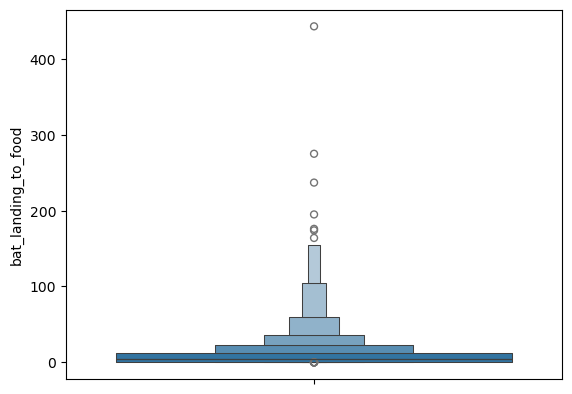

In [43]:
sns.boxenplot(y=data['bat_landing_to_food'])

<Axes: xlabel='bat_landing_to_food', ylabel='Count'>

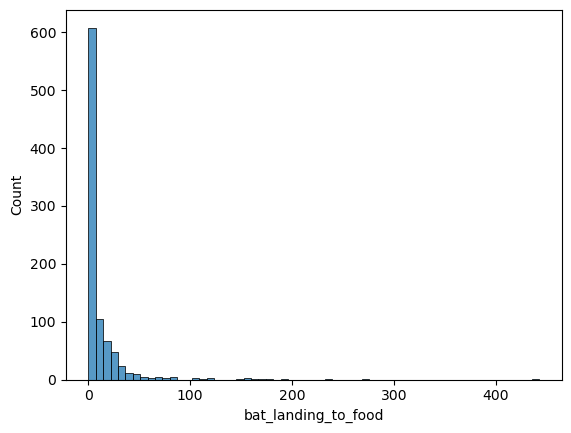

In [44]:
sns.histplot(data['bat_landing_to_food'])